---
# Pre-TARE Adoption KPIs: Spark Gap, Thermal COP, Break-Even COP
---

**Author:** Jordan M. Joseph, PhD — Carnegie Mellon University

Computes adoption economics metrics that can be calculated directly from EUSS
data and EIA fuel prices, without requiring a TARE model run.

**Workflow:** Load EUSS data → spark gap → thermal COP & AFUE → break-even COP → maps

**Batch Mode:** Set `input_measure_package` before calling via `%run -i` to skip prompts.

See `README_adoption_kpis.md` for methodology notes and design decisions.

---
## Step 0: Imports and Configuration
---

In [13]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from config import PROJECT_ROOT
from cmu_tare_model.constants import ALLOWED_HOUSING_TYPES, VALID_MENU_MPS, VERBOSE

from cmu_tare_model.adoption_kpis.kpi_functions import (
    mp_to_upgrade,
    load_euss_baseline,
    load_euss_upgrade,
    calculate_price_ratios,
    compute_thermal_cop_by_state,
    compute_breakeven_cop,
    compute_spark_gap_metrics,
    FUEL_PRICES_PATH,
    SHAPEFILE_PATH,
    HEATING_LOAD_COL,
)
from cmu_tare_model.adoption_kpis.visualize_geospatial_data import (
    prepare_state_geodataframe,
    create_choropleth_map,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)

print("✓ Imports loaded")
print(f"Project root: {PROJECT_ROOT}")

✓ Imports loaded
Project root: c:\users\jorda\desktop\projects\cmu-tare-model


---
## Step 0b: Measure Package Selection
---

In [2]:
SELECTABLE_MPS = [mp for mp in VALID_MENU_MPS if mp != 0]

try:
    _ = input_measure_package
    batch_mode = True
    selected_mps = [int(input_measure_package)]
    print(f"BATCH MODE: Running for MP{selected_mps[0]}")
except NameError:
    batch_mode = False
    print(f"Available measure packages: {SELECTABLE_MPS}")
    mp_input = input("Enter MP numbers (comma-separated, or 'all'): ").strip()
    if mp_input.lower() == 'all':
        selected_mps = SELECTABLE_MPS
    else:
        selected_mps = [int(x.strip()) for x in mp_input.split(',') if x.strip().isdigit()]
        selected_mps = [mp for mp in selected_mps if mp in SELECTABLE_MPS]
    if not selected_mps:
        selected_mps = [4]
        print("No valid MPs selected. Defaulting to MP4.")

print(f"\nSelected measure packages: {selected_mps}")

Available measure packages: [3, 4, 8]

Selected measure packages: [3, 4]


---
## Step 1: Load EUSS Data
---

In [3]:
print("=" * 80)
print("STEP 1: LOAD EUSS DATA")
print("=" * 80)

df_baseline = load_euss_baseline()
print(f"  Baseline: {len(df_baseline):,} occupied SF homes")

upgrade_data = {}
for mp in selected_mps:
    upgrade_name = mp_to_upgrade(mp)
    print(f"\nLoading MP{mp} ({upgrade_name})...")
    upgrade_data[mp] = load_euss_upgrade(upgrade_name)
    print(f"  MP{mp}: {len(upgrade_data[mp]):,} applicable homes")

print(f"\n✓ STEP 1 COMPLETE")

STEP 1: LOAD EUSS DATA
Loading baseline from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\euss_data\resstock_amy2018_release_1.1\national\csv\baseline_metadata_and_annual_results.csv
  After occupancy filter: 482,597 / 548,916
  After housing type filter (['Single-Family Attached', 'Single-Family Detached']): 331,531
  Baseline: 331,531 occupied SF homes

Loading MP3 (upgrade03)...
Loading upgrade03 from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\euss_data\resstock_amy2018_release_1.1\national\csv\upgrade03_metadata_and_annual_results.csv
  After occupancy filter: 482,597 / 548,916
  After housing type filter: 331,531
  After applicability filter: 331,526
  MP3: 331,526 applicable homes

Loading MP4 (upgrade04)...
Loading upgrade04 from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\euss_data\resstock_amy2018_release_1.1\national\csv\upgrade04_metadata_and_annual_results.csv
  After occupancy filter: 482,597 / 548,916

---
## Step 2: Fuel Price Ratios (Spark Gap)
---

In [4]:
print("===== STEP 2: FUEL PRICE RATIOS (CSV, 2022 nominal) =====")
df_prices_csv = calculate_price_ratios(FUEL_PRICES_PATH, year=2022)
print(f"✓ Loaded price data for {len(df_prices_csv)} states")

print(f"\nSpark Gap — Mean: {df_prices_csv['spark_gap'].mean():.2f}, "
      f"Range: {df_prices_csv['spark_gap'].min():.2f}–{df_prices_csv['spark_gap'].max():.2f}")

print(f"\n--- Top 5 (highest spark gap) ---")
print(df_prices_csv.head(5).to_string(index=False))
print(f"\n--- Bottom 5 (lowest spark gap) ---")
print(df_prices_csv.tail(5).to_string(index=False))

# TODO: Load updated 10-year average residential fuel price data when available
print("\n⚠ 10-year average prices: PLACEHOLDER — awaiting updated data")

===== STEP 2: FUEL PRICE RATIOS (CSV, 2022 nominal) =====
✓ Loaded price data for 51 states

Spark Gap — Mean: 3.15, Range: 1.61–6.35

--- Top 5 (highest spark gap) ---
state  state_name  elec_price_kwh  gas_price_kwh  elec_price_mmbtu  gas_price_mmbtu  spark_gap
   AK      Alaska          0.2310         0.0364             67.70            10.66       6.35
   MI    Michigan          0.1786         0.0371             52.34            10.89       4.81
   WI   Wisconsin          0.1562         0.0372             45.78            10.91       4.19
   NY    New York          0.2208         0.0537             64.71            15.73       4.11
   CT Connecticut          0.2461         0.0603             72.12            17.67       4.08

--- Bottom 5 (lowest spark gap) ---
state     state_name  elec_price_kwh  gas_price_kwh  elec_price_mmbtu  gas_price_mmbtu  spark_gap
   HI         Hawaii          0.4303         0.1887            126.11            55.30       2.28
   AZ        Arizona        

---
## Step 3: Thermal COP and Baseline AFUE
---

In [5]:
cop_results = {}

for mp in selected_mps:
    print(f"\n{'=' * 80}")
    print(f"STEP 3: THERMAL COP & BASELINE AFUE (MP{mp}, Natural Gas homes)")
    print(f"{'=' * 80}")

    cop_results[mp] = compute_thermal_cop_by_state(
        df_baseline, upgrade_data[mp], fuel_filter='Natural Gas', verbose=True
    )

    df_cop_mp = cop_results[mp]
    print(f"\n--- Top 5 by COP (MP{mp}) ---")
    print(df_cop_mp.sort_values('thermal_cop', ascending=False).head(5)[
        ['state', 'thermal_cop', 'baseline_afue', 'fans_pumps_pct', 'home_count']
    ].to_string(index=False))

    print(f"\n--- Bottom 5 by COP (MP{mp}) ---")
    print(df_cop_mp.sort_values('thermal_cop', ascending=True).head(5)[
        ['state', 'thermal_cop', 'baseline_afue', 'fans_pumps_pct', 'home_count']
    ].to_string(index=False))

    # Validation: heating load consistency
    common_ids = df_baseline.index.intersection(upgrade_data[mp].index)
    Q_baseline = df_baseline.loc[common_ids, HEATING_LOAD_COL].fillna(0)
    Q_upgrade = upgrade_data[mp].loc[common_ids, HEATING_LOAD_COL].fillna(0)
    mask = Q_baseline > 0
    pct_diff = ((Q_upgrade[mask] - Q_baseline[mask]) / Q_baseline[mask]).median()
    print(f"\nHeating load consistency: {pct_diff:.1%} median difference (expect ±5–10%)")

primary_mp = selected_mps[0]
df_cop = cop_results[primary_mp]
df_upgrade_primary = upgrade_data[primary_mp]
print(f"\n✓ STEP 3 COMPLETE — Primary MP: {primary_mp}")


STEP 3: THERMAL COP & BASELINE AFUE (MP3, Natural Gas homes)
Matched homes (baseline ∩ upgrade): 331,526
Filtered to 'Natural Gas': 180,939 / 331,526 homes (54.6%)
Excluded 683 homes with zero baseline heating (180,256 remaining)

--- Thermal COP Summary (Natural Gas) ---
States: 49
Mean:   2.21
Median: 2.20
Range:  1.53 - 3.05
✓ All states within expected COP range (1.5–5.0)

--- Baseline AFUE Summary (Natural Gas) ---
Mean:   0.80
Median: 0.80
Range:  0.75 - 0.82

--- Fan/Pump Energy as % of Total HP Electricity ---
Mean:   3.8%
Range:  1.7% - 5.8%

--- Top 5 by COP (MP3) ---
state  thermal_cop  baseline_afue  fans_pumps_pct  home_count
   CA     3.054755       0.801801        4.001501       24571
   FL     2.893052       0.794453        5.682569        1084
   LA     2.758595       0.799742        5.761571        2139
   TX     2.748806       0.804379        5.035227       12362
   DC     2.715392       0.752035        4.055966         338

--- Bottom 5 by COP (MP3) ---
state  ther

---
## Step 4: Break-Even COP and Merged Metrics
---

In [6]:
print("=" * 80)
print("STEP 4: BREAK-EVEN COP & MERGED METRICS")
print("=" * 80)

# --- 4a: Compute break-even COP for multiple AFUE scenarios ---
# ASSUMPTION: 2022 EIA state-level residential prices; 2024 data not available.
afue_scenarios = [0.80, 0.90, 0.95, 1.00]
df_breakeven = compute_breakeven_cop(df_prices_csv, afue_scenarios=afue_scenarios)
print(f"✓ Break-even COP computed for {len(df_breakeven)} states, "
      f"AFUE scenarios: {afue_scenarios}")

print(f"\nBreak-even COP @90% AFUE — "
      f"Mean: {df_breakeven['breakeven_cop_90'].mean():.2f}, "
      f"Range: {df_breakeven['breakeven_cop_90'].min():.2f}–"
      f"{df_breakeven['breakeven_cop_90'].max():.2f}")

# --- 4b: Merge prices + COP + break-even into single state-level table ---
df_spark = compute_spark_gap_metrics(
    df_prices_csv, df_cop, df_breakeven=df_breakeven, verbose=True
)

# --- 4c: Validate against Jenkins Heat Pump Map reference values (90% AFUE) ---
# Source: Jenkins et al., break-even COP at 90% AFUE
# Note: Jenkins values may assume different price year; deviations documented below.
jenkins_ref = {
    'FL': 1.50, 'PA': 3.51, 'MN': 3.90,
    'AK': 5.69, 'CA': 4.49, 'MA': 3.60,
}
print("\n--- Jenkins Validation (break-even COP @90% AFUE, ±0.05) ---")
print(f"{'State':<6} {'Computed':>10} {'Jenkins':>10} {'Diff':>8} {'Pass':>6}")
print("-" * 44)
for st, ref_val in sorted(jenkins_ref.items()):
    row = df_spark[df_spark['state'] == st]
    if len(row) == 0:
        print(f"{st:<6} {'N/A':>10} {ref_val:>10.2f} {'—':>8} {'SKIP':>6}")
        continue
    computed = row['breakeven_cop_90'].values[0]
    diff = computed - ref_val
    passed = abs(diff) <= 0.05
    print(f"{st:<6} {computed:>10.2f} {ref_val:>10.2f} {diff:>+8.2f} {'✓' if passed else '✗':>6}")

# --- 4d: Cross-validation (effective COP vs break-even COP) ---
print("\n--- Cross-Validation: Effective COP vs Break-Even @90% ---")
warm_states = ['FL', 'GA', 'SC', 'TX', 'LA']
cold_states = ['MN', 'WI', 'VT', 'ND', 'ME']
for label, states in [('Warm', warm_states), ('Cold', cold_states)]:
    subset = df_spark[df_spark['state'].isin(states)].copy()
    if len(subset) == 0:
        continue
    subset['cop_minus_be'] = subset['thermal_cop'] - subset['breakeven_cop_90']
    print(f"\n{label} states:")
    print(f"  {'State':<6} {'COP':>6} {'BE_90':>6} {'Diff':>8} {'HP Wins?':>10}")
    for _, r in subset.iterrows():
        hp_wins = r['thermal_cop'] > r['breakeven_cop_90']
        print(f"  {r['state']:<6} {r['thermal_cop']:>6.2f} "
              f"{r['breakeven_cop_90']:>6.2f} {r['cop_minus_be']:>+8.2f} "
              f"{'Yes' if hp_wins else 'No':>10}")

print(f"\n✓ STEP 4 COMPLETE")

STEP 4: BREAK-EVEN COP & MERGED METRICS
✓ Break-even COP computed for 51 states, AFUE scenarios: [0.8, 0.9, 0.95, 1.0]

Break-even COP @90% AFUE — Mean: 2.84, Range: 1.45–5.72

--- Spark Gap Metrics Summary (49 states) ---
Break-even COP @90% AFUE — Mean: 2.79, Range: 1.45–4.33
States where effective COP < break-even @90%: 33/49

--- Jenkins Validation (break-even COP @90% AFUE, ±0.05) ---
State    Computed    Jenkins     Diff   Pass
--------------------------------------------
AK            N/A       5.69        —   SKIP
CA           3.52       4.49    -0.97      ✗
FL           1.45       1.50    -0.05      ✗
MA           3.48       3.60    -0.12      ✗
MN           3.22       3.90    -0.68      ✗
PA           2.92       3.51    -0.59      ✗

--- Cross-Validation: Effective COP vs Break-Even @90% ---

Warm states:
  State     COP  BE_90     Diff   HP Wins?
  SC       2.60   2.38    +0.22        Yes
  TX       2.75   2.29    +0.46        Yes
  LA       2.76   2.24    +0.52        Yes
 

---
## Step 5: Geospatial Visualization
---

In [7]:
gdf_conus = None
gdf_alaska = None

try:
    print(f"Loading shapefile from: {SHAPEFILE_PATH}")
    gdf_states_raw = gpd.read_file(SHAPEFILE_PATH)
    _, gdf_conus, gdf_alaska = prepare_state_geodataframe(gdf_states_raw, df_spark, merge_col='state')
    print(f"  CONUS: {len(gdf_conus)}, Alaska: {len(gdf_alaska)}")
    print("✓ Geodataframe prepared")
except FileNotFoundError:
    print(f"⚠ Shapefile not found at {SHAPEFILE_PATH} — skipping maps")
except Exception as e:
    print(f"⚠ Could not load shapefile: {e}")

Loading shapefile from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\electricity_ng_price_ratio\nhgis0011_shapefile_tl2015_us_state_2015\US_state_2015.shp
  CONUS: 49, Alaska: 0
✓ Geodataframe prepared


Generating choropleth maps...
  Saved: c:\users\jorda\desktop\projects\cmu-tare-model\state_spark_gap_map_2022.png


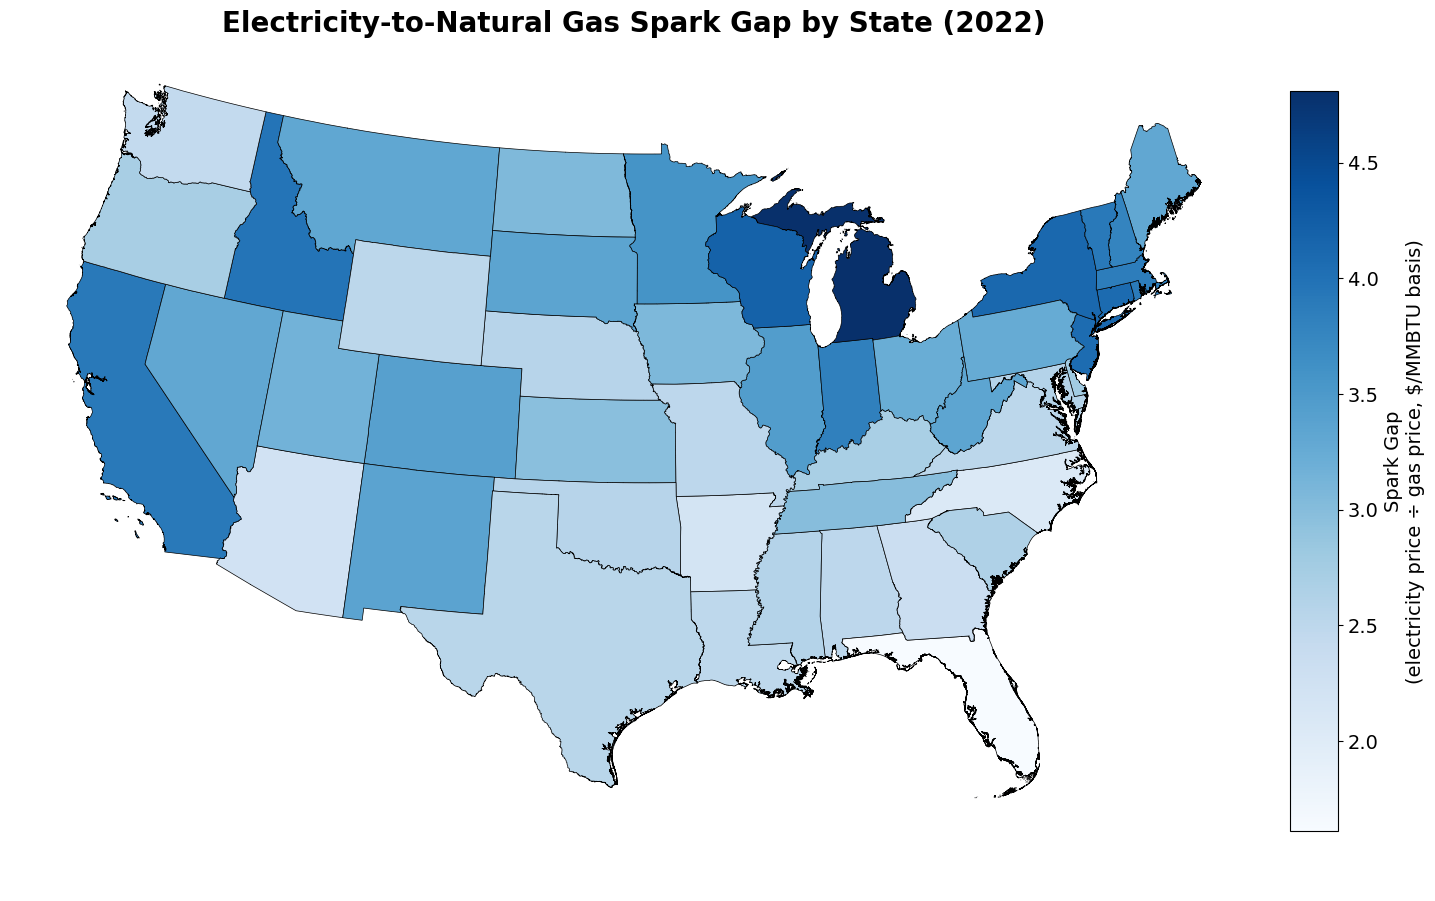

  Saved: c:\users\jorda\desktop\projects\cmu-tare-model\state_thermal_cop_mp3_mp4_map_2022.png


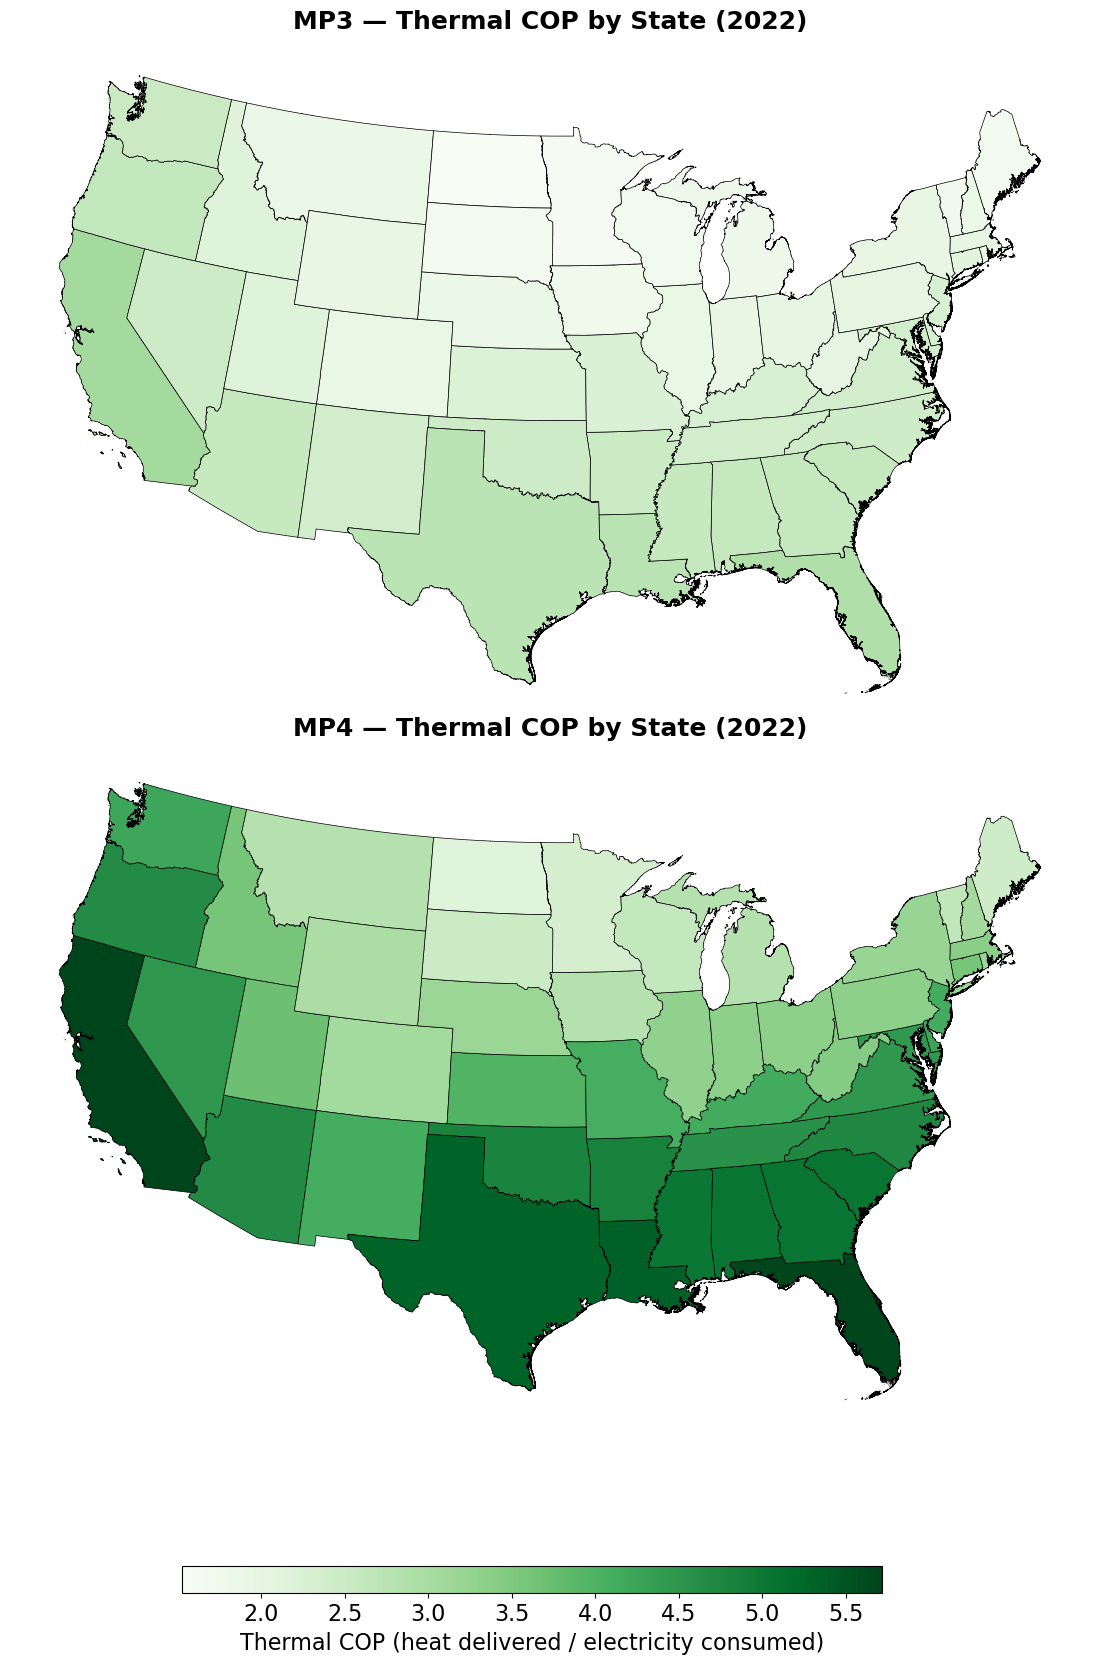

  Saved: c:\users\jorda\desktop\projects\cmu-tare-model\state_breakeven_cop_90_map_2022.png


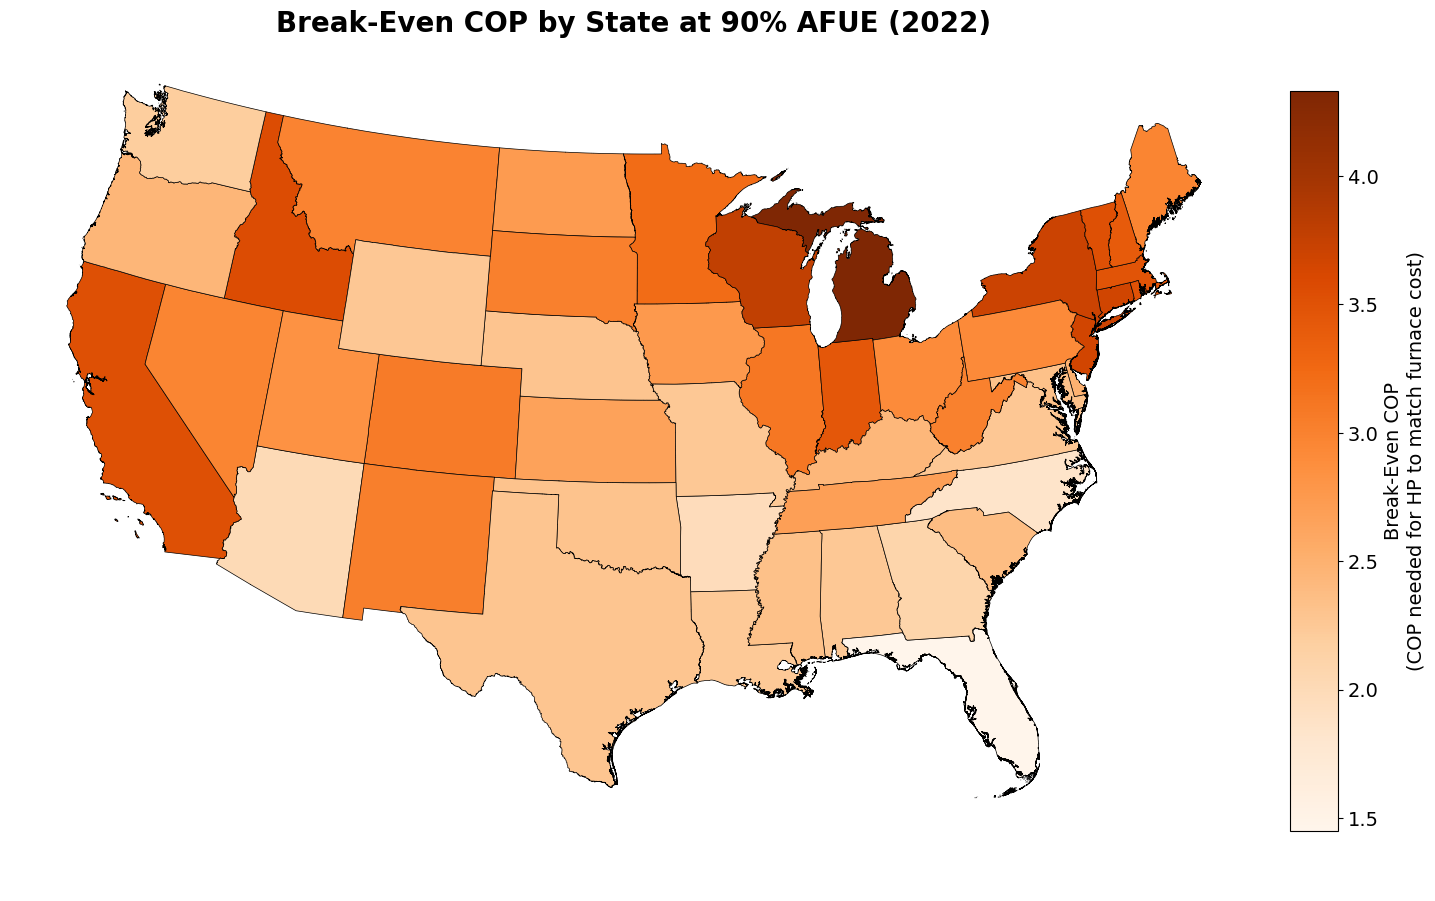

✓ Maps generated


In [26]:
# if gdf_conus is not None and gdf_alaska is not None:
#     print("Generating choropleth maps...")

#     # --- Spark gap (blue) ---
#     create_choropleth_map(
#         gdf_conus, gdf_alaska, column='spark_gap',
#         title='Electricity-to-Natural Gas Spark Gap by State (2022)',
#         cbar_label='Spark Gap\n(electricity price ÷ gas price, $/MMBTU basis)',
#         output_path=os.path.join(PROJECT_ROOT, "state_spark_gap_map_2022.png"),
#         cmap='Blues', show_plot=True,
#     )

#     # --- Thermal COP: MP3 top / MP4 bottom with shared color scale (greens) ---
#     cop_mps = [mp for mp in [3, 4] if mp in cop_results]
#     if len(cop_mps) >= 2:
#         # Build per-MP geodataframes and find shared color range
#         gdf_cop_panels = {}
#         all_vals = pd.Series(dtype=float)
#         for mp_num in cop_mps:
#             df_spark_mp = compute_spark_gap_metrics(df_prices_csv, cop_results[mp_num])
#             _, gdf_c, gdf_a = prepare_state_geodataframe(
#                 gdf_states_raw, df_spark_mp, merge_col='state'
#             )
#             gdf_cop_panels[mp_num] = (gdf_c, gdf_a)
#             all_vals = pd.concat([all_vals, gdf_c['thermal_cop'], gdf_a['thermal_cop']])

#         shared_norm = mcolors.Normalize(vmin=all_vals.dropna().min(), vmax=all_vals.dropna().max())
#         col = 'thermal_cop'
#         nrows = len(cop_mps)

#         fig, axes_grid = plt.subplots(nrows, 1, figsize=(14, 9 * nrows), facecolor='white')
#         if nrows == 1:
#             axes_grid = [axes_grid]

#         for i, mp_num in enumerate(cop_mps):
#             gdf_c, gdf_a = gdf_cop_panels[mp_num]
#             ax = axes_grid[i]

#             gdf_c.plot(ax=ax, column=col, cmap='Greens', edgecolor='black',
#                        linewidth=0.5, norm=shared_norm, legend=False)
#             ax.set_axis_off()
#             ax.set_title(f'MP{mp_num} — Thermal COP by State (2022)',
#                          fontsize=18, fontweight='bold', pad=12)

#             # Alaska inset — only plot if data exists
#             inset_bounds = ax.get_position()
#             ax_ak = fig.add_axes([
#                 inset_bounds.x0, inset_bounds.y0,
#                 inset_bounds.width * 0.22, inset_bounds.height * 0.28,
#             ])
#             if not gdf_a.empty:
#                 gdf_a.plot(ax=ax_ak, column=col, cmap='Greens', edgecolor='black',
#                            linewidth=0.5, norm=shared_norm, legend=False)
#             ax_ak.set_axis_off()

#         # Shared colorbar — bottom center
#         cax = fig.add_axes([0.25, 0.02, 0.50, 0.015])
#         sm = plt.cm.ScalarMappable(cmap='Greens', norm=shared_norm)
#         sm.set_array([])
#         cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
#         cbar.set_label('Thermal COP (heat delivered / electricity consumed)', fontsize=16)
#         cax.tick_params(labelsize=16)

#         fig.subplots_adjust(hspace=0.04)
#         output = os.path.join(PROJECT_ROOT, "state_thermal_cop_mp3_mp4_map_2022.png")
#         fig.savefig(output, dpi=300, bbox_inches='tight', facecolor='white')
#         print(f"  Saved: {output}")
#         plt.show()
#     elif len(cop_mps) == 1:
#         create_choropleth_map(
#             gdf_conus, gdf_alaska, column='thermal_cop',
#             title=f'Heat Pump Thermal COP by State (MP{cop_mps[0]}, 2022)',
#             cbar_label='Thermal COP\n(heat delivered / electricity consumed)',
#             output_path=os.path.join(PROJECT_ROOT, f"state_thermal_cop_mp{cop_mps[0]}_map_2022.png"),
#             cmap='Greens', show_plot=True,
#         )
#     else:
#         print("⚠ No thermal COP results for MP3 or MP4 — skipping COP maps")

#     # --- Break-even COP at 90% AFUE (orange) ---
#     create_choropleth_map(
#         gdf_conus, gdf_alaska, column='breakeven_cop_90',
#         title='Break-Even COP by State at 90% AFUE (2022)',
#         cbar_label='Break-Even COP\n(COP needed for HP to match furnace cost)',
#         output_path=os.path.join(PROJECT_ROOT, "state_breakeven_cop_90_map_2022.png"),
#         cmap='Oranges', show_plot=True,
#     )

#     print("✓ Maps generated")
# else:
#     print("⚠ Maps skipped — no geodataframe available")

In [ ]:
if gdf_conus is not None and gdf_alaska is not None:
    print("Generating choropleth maps...")

    # --- Spark gap (blue) ---
    create_choropleth_map(
        gdf_conus, gdf_alaska, column='spark_gap',
        title='Electricity-to-Natural Gas Spark Gap by State (2022)',
        cbar_label='Spark Gap\n(electricity price ÷ gas price, $/MMBTU basis)',
        output_path=os.path.join(PROJECT_ROOT, "state_spark_gap_map_2022.png"),
        cmap='Blues', show_plot=True,
    )

else:
    print("⚠ Maps skipped — no geodataframe available")

Generating choropleth maps...
  Saved: c:\users\jorda\desktop\projects\cmu-tare-model\state_thermal_cop_mp3_mp4_map_2022.png


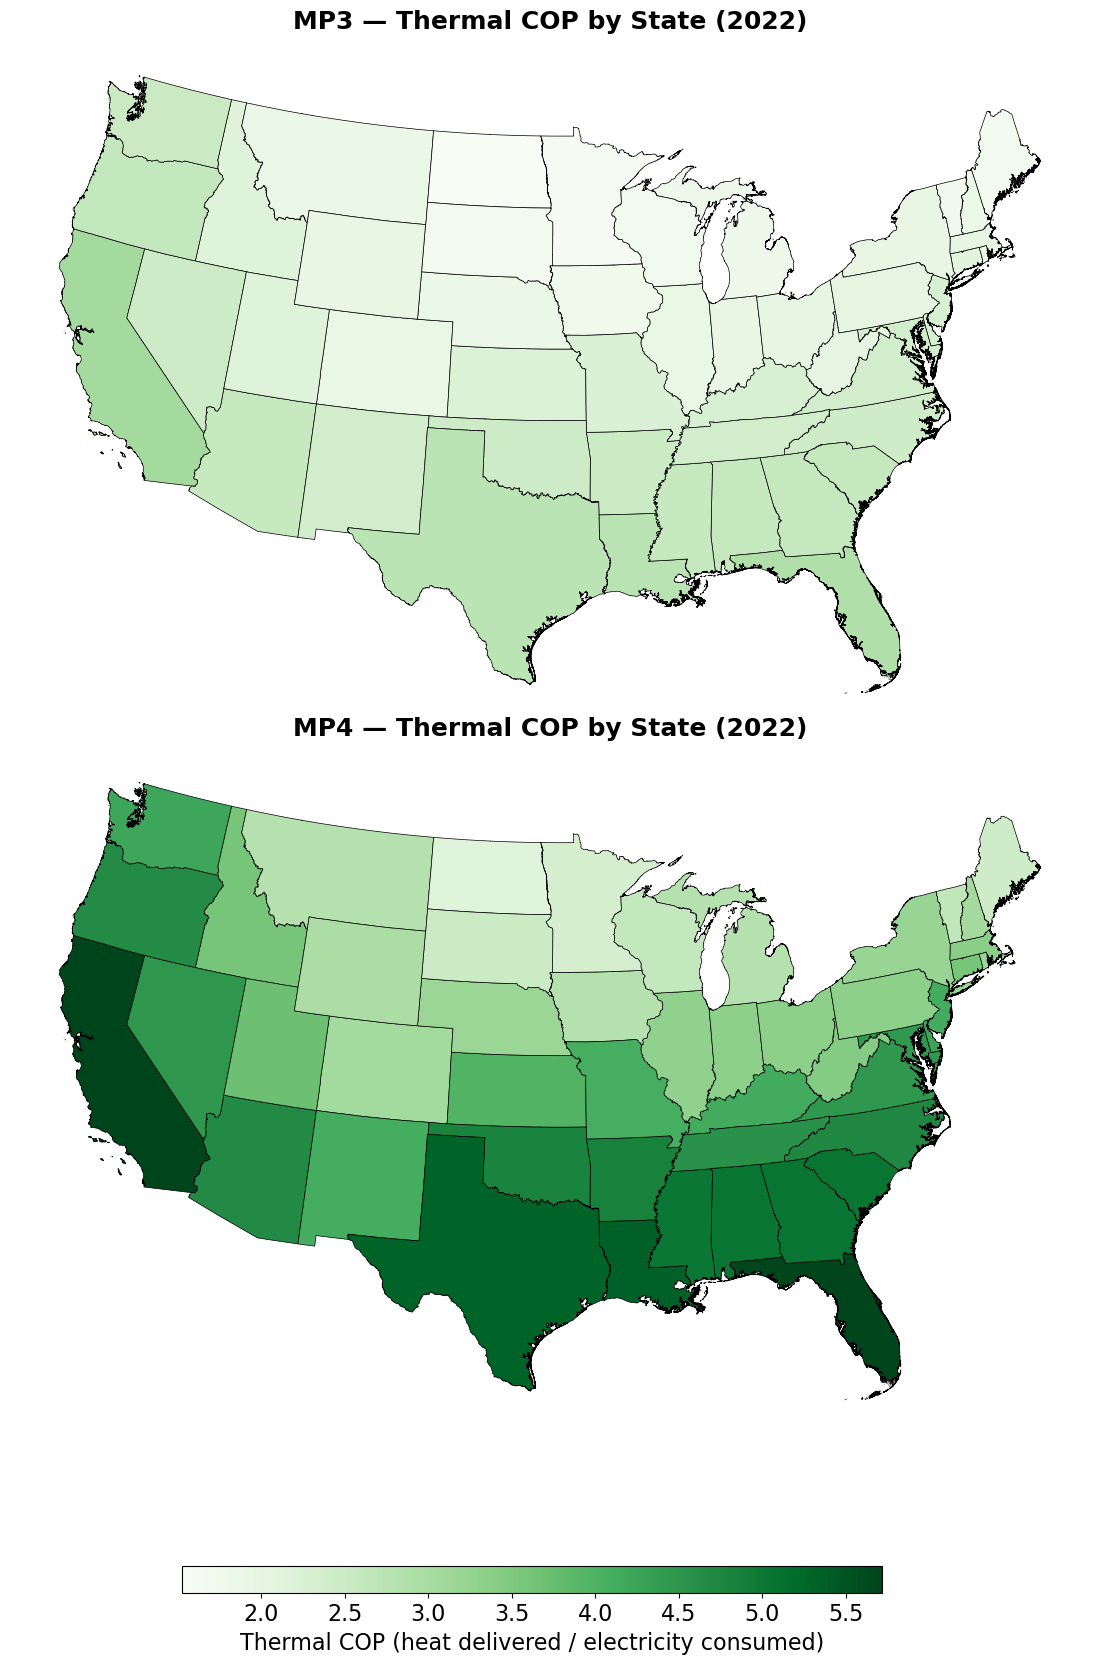

✓ Maps generated


In [27]:
if gdf_conus is not None and gdf_alaska is not None:
    print("Generating choropleth maps...")

    # --- Thermal COP: MP3 top / MP4 bottom with shared color scale (greens) ---
    cop_mps = [mp for mp in [3, 4] if mp in cop_results]
    if len(cop_mps) >= 2:
        # Build per-MP geodataframes and find shared color range
        gdf_cop_panels = {}
        all_vals = pd.Series(dtype=float)
        for mp_num in cop_mps:
            df_spark_mp = compute_spark_gap_metrics(df_prices_csv, cop_results[mp_num])
            _, gdf_c, gdf_a = prepare_state_geodataframe(
                gdf_states_raw, df_spark_mp, merge_col='state'
            )
            gdf_cop_panels[mp_num] = (gdf_c, gdf_a)
            all_vals = pd.concat([all_vals, gdf_c['thermal_cop'], gdf_a['thermal_cop']])

        shared_norm = mcolors.Normalize(vmin=all_vals.dropna().min(), vmax=all_vals.dropna().max())
        col = 'thermal_cop'
        nrows = len(cop_mps)

        fig, axes_grid = plt.subplots(nrows, 1, figsize=(14, 9 * nrows), facecolor='white')
        if nrows == 1:
            axes_grid = [axes_grid]

        for i, mp_num in enumerate(cop_mps):
            gdf_c, gdf_a = gdf_cop_panels[mp_num]
            ax = axes_grid[i]

            gdf_c.plot(ax=ax, column=col, cmap='Greens', edgecolor='black',
                       linewidth=0.5, norm=shared_norm, legend=False)
            ax.set_axis_off()
            ax.set_title(f'MP{mp_num} — Thermal COP by State (2022)',
                         fontsize=18, fontweight='bold', pad=12)

            # Alaska inset — only plot if data exists
            inset_bounds = ax.get_position()
            ax_ak = fig.add_axes([
                inset_bounds.x0, inset_bounds.y0,
                inset_bounds.width * 0.22, inset_bounds.height * 0.28,
            ])
            if not gdf_a.empty:
                gdf_a.plot(ax=ax_ak, column=col, cmap='Greens', edgecolor='black',
                           linewidth=0.5, norm=shared_norm, legend=False)
            ax_ak.set_axis_off()

        # Shared colorbar — bottom center
        cax = fig.add_axes([0.25, 0.02, 0.50, 0.015])
        sm = plt.cm.ScalarMappable(cmap='Greens', norm=shared_norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
        cbar.set_label('Thermal COP (heat delivered / electricity consumed)', fontsize=16)
        cax.tick_params(labelsize=16)

        fig.subplots_adjust(hspace=0.04)
        output = os.path.join(PROJECT_ROOT, "state_thermal_cop_mp3_mp4_map_2022.png")
        fig.savefig(output, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"  Saved: {output}")
        plt.show()
    elif len(cop_mps) == 1:
        create_choropleth_map(
            gdf_conus, gdf_alaska, column='thermal_cop',
            title=f'Heat Pump Thermal COP by State (MP{cop_mps[0]}, 2022)',
            cbar_label='Thermal COP\n(heat delivered / electricity consumed)',
            output_path=os.path.join(PROJECT_ROOT, f"state_thermal_cop_mp{cop_mps[0]}_map_2022.png"),
            cmap='Greens', show_plot=True,
        )
    else:
        print("⚠ No thermal COP results for MP3 or MP4 — skipping COP maps")

    print("✓ Maps generated")
else:
    print("⚠ Maps skipped — no geodataframe available")

Generating choropleth maps...
  Saved: c:\users\jorda\desktop\projects\cmu-tare-model\state_breakeven_cop_90_map_2022.png


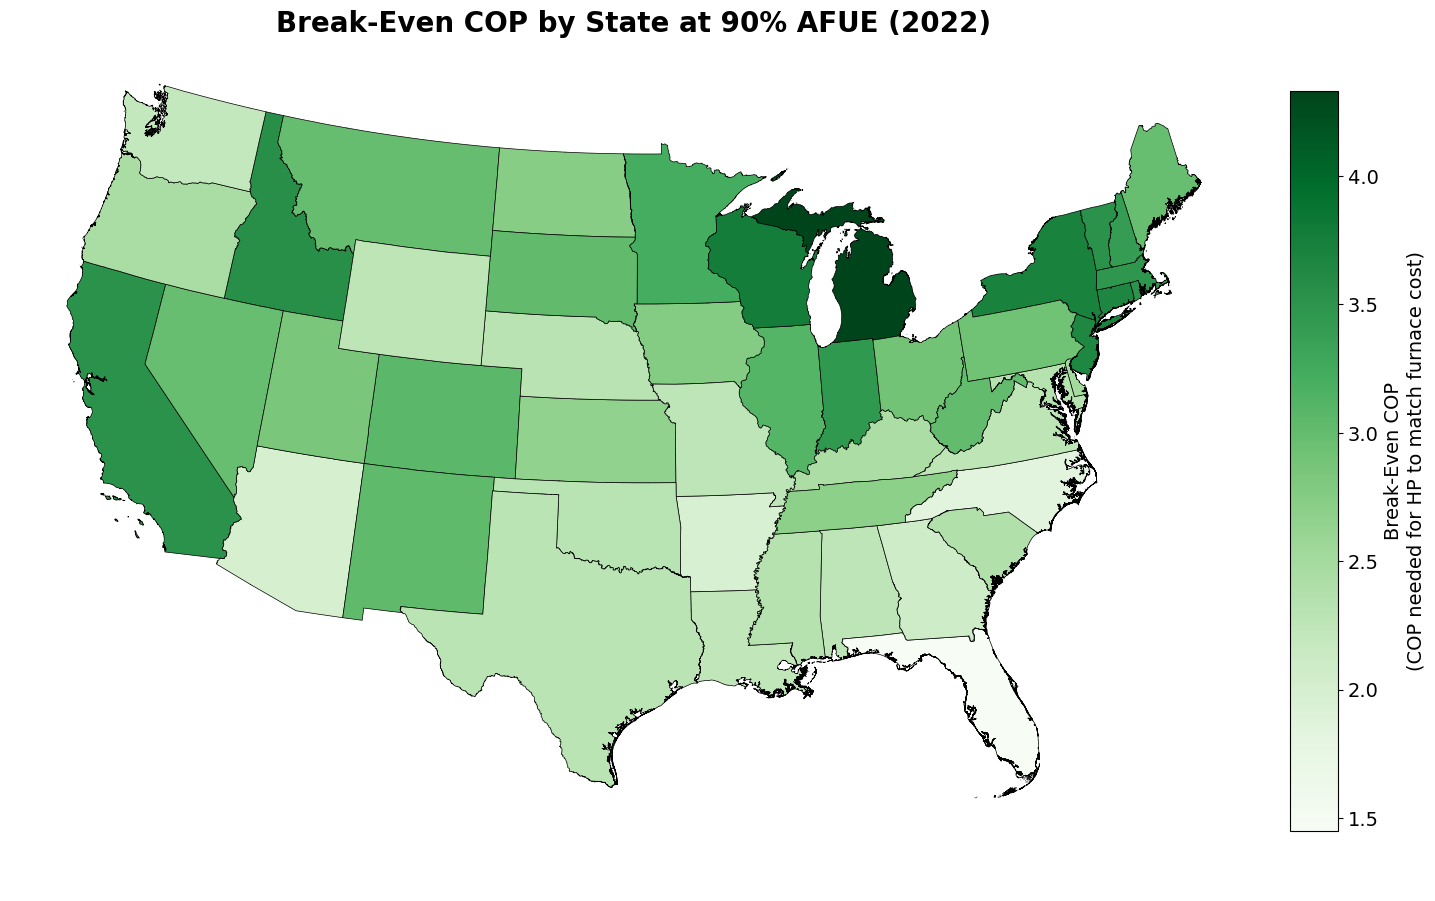

✓ Maps generated


In [28]:
from typing import Optional, Tuple
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def create_choropleth_map(
    gdf_conus: gpd.GeoDataFrame,
    gdf_alaska: gpd.GeoDataFrame,
    column: str,
    title: str,
    cbar_label: str,
    year: int = 2022,
    output_path:Optional[str] = None,
    figsize: Tuple[int, int] = (16, 10),
    dpi: int = 300,
    cmap: str = 'Blues',
    norm=None,
    show_plot: bool = True
) -> Optional[str]:
    """
    Create a choropleth map with CONUS main panel and Alaska inset.

    Pass a matplotlib Normalize (e.g. TwoSlopeNorm) via `norm` for diverging
    maps; otherwise linear normalization is derived from the data automatically.
    """
    plot_kw = dict(column=column, cmap=cmap, edgecolor='black', linewidth=0.5, legend=False)

    if norm is not None:
        plot_kw['norm'] = norm
    else:
        vals = pd.concat([gdf_conus[column], gdf_alaska[column]]).dropna()
        norm = mcolors.Normalize(vmin=vals.min(), vmax=vals.max())
        plot_kw['vmin'], plot_kw['vmax'] = vals.min(), vals.max()

    fig = plt.figure(figsize=figsize, facecolor='white')
    ax_main = fig.add_axes([0.02, 0.02, 0.78, 0.90])
    ax_ak = fig.add_axes([0.02, 0.02, 0.22, 0.25])

    gdf_conus.plot(ax=ax_main, **plot_kw)
    ax_main.set_axis_off()
    ax_main.set_title(title, fontsize=20, fontweight='bold', pad=12)

    if not gdf_alaska.empty:
        gdf_alaska.plot(ax=ax_ak, **plot_kw)
    ax_ak.set_axis_off()

    # Colorbar — matplotlib handles tick placement natively for any norm
    cax = fig.add_axes([0.82, 0.08, 0.03, 0.74])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cax, label=cbar_label).ax.yaxis.label.set_fontsize(14)
    cax.tick_params(labelsize=14)

    if output_path:
        fig.savefig(output_path, dpi=dpi, bbox_inches='tight', facecolor='white')
        print(f"  Saved: {output_path}")
    if show_plot:
        plt.show()
    else:
        plt.close(fig)
    return output_path if output_path else None


if gdf_conus is not None and gdf_alaska is not None:
    print("Generating choropleth maps...")

    # --- Break-even COP at 90% AFUE (green) ---
    create_choropleth_map(
        gdf_conus, gdf_alaska, column='breakeven_cop_90',
        title='Break-Even COP by State at 90% AFUE (2022)',
        cbar_label='Break-Even COP\n(COP needed for HP to match furnace cost)',
        output_path=os.path.join(PROJECT_ROOT, "state_breakeven_cop_90_map_2022.png"),
        cmap='Greens', show_plot=True,
    )

    print("✓ Maps generated")
else:
    print("⚠ Maps skipped — no geodataframe available")

---
## Display Results
---

In [9]:
print("===== STATE PRICE RATIOS (2022 nominal) =====\n")
display(df_prices_csv)

for mp in selected_mps:
    print(f"\n===== THERMAL COP & AFUE (MP{mp}, NG homes) =====\n")
    display(cop_results[mp].sort_values('thermal_cop', ascending=False)[
        ['state', 'thermal_cop', 'baseline_afue', 'fans_pumps_pct', 'home_count']
    ])

# --- Comparison table: spark gap, break-even COP, effective COP ---
print(f"\n===== SPARK GAP & BREAK-EVEN COP vs EFFECTIVE COP (MP{primary_mp}) =====\n")

df_display = df_spark[[
    'state', 'state_name', 'spark_gap',
    'breakeven_cop_80', 'breakeven_cop_90', 'breakeven_cop_95', 'breakeven_cop_100',
    'thermal_cop', 'baseline_afue',
]].copy()

# Flag whether the heat pump beats the break-even threshold at 90% AFUE
df_display['hp_beats_breakeven_90'] = df_display['thermal_cop'] > df_display['breakeven_cop_90']

display(df_display.sort_values('spark_gap', ascending=False).reset_index(drop=True))

===== STATE PRICE RATIOS (2022 nominal) =====



,state,state_name,elec_price_kwh,gas_price_kwh,elec_price_mmbtu,gas_price_mmbtu,spark_gap
0,AK,Alaska,0.2310,0.0364,67.70,10.66,6.35
1,MI,Michigan,0.1786,0.0371,52.34,10.89,4.81
2,WI,Wisconsin,0.1562,0.0372,45.78,10.91,4.19
3,NY,New York,0.2208,0.0537,64.71,15.73,4.11
4,CT,Connecticut,0.2461,0.0603,72.12,17.67,4.08
5,NJ,New Jersey,0.1674,0.0411,49.06,12.06,4.07
6,ID,Idaho,0.1037,0.0262,30.39,7.67,3.96
7,CA,California,0.2584,0.0662,75.73,19.39,3.91
8,VT,Vermont,0.1993,0.0509,58.41,14.93,3.91
9,RI,Rhode Island,0.2321,0.0597,68.02,17.49,3.89



===== THERMAL COP & AFUE (MP3, NG homes) =====



,state,thermal_cop,baseline_afue,fans_pumps_pct,home_count
3,CA,3.054755,0.801801,4.001501,24571
8,FL,2.893052,0.794453,5.682569,1084
16,LA,2.758595,0.799742,5.761571,2139
41,TX,2.748806,0.804379,5.035227,12362
6,DC,2.715392,0.752035,4.055966,338
35,OR,2.618561,0.820170,3.725680,2183
0,AL,2.608147,0.805110,4.792433,1853
38,SC,2.603092,0.808995,4.670975,1580
9,GA,2.598895,0.812388,4.839350,5111
2,AZ,2.588321,0.823168,5.414082,2757



===== THERMAL COP & AFUE (MP4, NG homes) =====



,state,thermal_cop,baseline_afue,fans_pumps_pct,home_count
3,CA,5.719542,0.801801,5.075078,24571
8,FL,5.697018,0.794453,5.459375,1084
16,LA,5.345519,0.799742,5.496742,2139
41,TX,5.303021,0.804379,5.558138,12362
0,AL,5.058210,0.805110,5.564781,1853
9,GA,5.057374,0.812388,5.699106,5111
38,SC,5.056874,0.808995,5.632238,1580
23,MS,5.024481,0.810445,5.541313,1219
6,DC,4.980642,0.752035,4.335234,338
1,AR,4.830257,0.804689,5.518244,1582



===== SPARK GAP & BREAK-EVEN COP vs EFFECTIVE COP (MP3) =====



,state,state_name,spark_gap,breakeven_cop_80,breakeven_cop_90,breakeven_cop_95,breakeven_cop_100,thermal_cop,baseline_afue,hp_beats_breakeven_90
0,MI,Michigan,4.81,3.85,4.33,4.57,4.81,1.785815,0.809416,False
1,WI,Wisconsin,4.19,3.35,3.77,3.98,4.19,1.699153,0.804310,False
2,NY,New York,4.11,3.29,3.70,3.90,4.11,1.974215,0.793466,False
3,CT,Connecticut,4.08,3.26,3.67,3.88,4.08,2.085552,0.803036,False
4,NJ,New Jersey,4.07,3.26,3.66,3.87,4.07,2.294246,0.795664,False
5,ID,Idaho,3.96,3.17,3.56,3.76,3.96,2.154783,0.824162,False
6,CA,California,3.91,3.13,3.52,3.71,3.91,3.054755,0.801801,False
7,VT,Vermont,3.91,3.13,3.52,3.71,3.91,1.731443,0.805144,False
8,RI,Rhode Island,3.89,3.11,3.50,3.70,3.89,1.936985,0.802848,False
9,MA,Massachusetts,3.87,3.10,3.48,3.68,3.87,2.012107,0.800042,False
